# Plot hydrograph of simulation and observation of Hawkesbury catchment

In [3]:
%load_ext autoreload
%autoreload 2

In [4]:
#pip install bomwater

In [5]:
#help(gg.gauge_getter)

In [6]:
#!pip install -e /datasets/work/lw-hydrofct/work/common/Software/xarray_utilities/

In [7]:
import sys
print("Python version")
print (sys.version)
#print("Version info.")
#print (sys.version_info)

Python version
3.10.11 | packaged by conda-forge | (main, May 10 2023, 18:58:44) [GCC 11.3.0]


### Import Various Necessary Libraries Dask and Related Libraries

In [8]:
from dask_jobqueue import SLURMCluster
from dask.distributed import Client
import dask
import os
import uuid

In [9]:
os.environ['USE_PYGEOS'] = '0'
import random
import datetime as dt
#from decimal import *#
import geopandas as gpd 
import fiona 
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import matplotlib.pyplot as plt
import xarray as xr
from PIL import Image
import mdba_gauge_getter as gg
from matplotlib.collections import LineCollection
from matplotlib.colors import ListedColormap, BoundaryNorm
import matplotlib.dates as mdates
import networkx as nx


### Add proxy binaries to path

In [10]:
pwd = !echo ${PWD}

In [11]:
pwd

['/datasets/work/d61-coastal-forecasting-wp3/work/shr015/Code/python_singularity/swift_notebooks/sim_verf/Hawkesbury']

### Extend the local python paths with some network drives

In [12]:
extension_python_paths = [ os.environ["HOME"] + '/lib/python3.10/site-packages']
[sys.path.append(an_ext) for an_ext in extension_python_paths]

[None]

### Specify a python exe used by SLURM to create the dask workers


In [13]:
containered_python_exe = f"srun --export=ALL -n $SLURM_NTASKS -c $SLURM_CPUS_PER_TASK   singularity run {os.environ['SINGULARITY_CONTAINER']} python"

### If you run this cell after creating a cluster it will close that cluster 

In [14]:
try:
    cluster.close()
except:
    pass

### Create a cluster
env_extra sets the worker specific environment parameters   

PYTHONPATH is set to include the extension ptyhon paths and the SINGULARITY_BINDPATH bind paths of this jupyter environment for passing to the workers

In [15]:
job_suffix = os.environ['JOB_SUFFIX'] if 'JOB_SUFFIX' in os.environ.keys() else str(uuid.uuid4())[:8]

In [16]:
job_suffix

'566b2047'

## List available project codes

In [17]:
!get_project_codes

/bin/bash: line 1: get_project_codes: command not found


In [18]:
defined = 'NC_IN_GLOB' in os.environ.keys()
if not defined:
    print("WARNING, project code note defined defaulting")
    project_code = 'OD-230112'
else:
    project_code = os.environ['NC_IN_GLOB']

WARNING, project code note defined defaulting


In [19]:
project_code

'OD-230112'

In [20]:
job_extra = f'--account {project_code}'

In [21]:
process_number = 2

In [22]:
cluster = SLURMCluster(
    cores=2, memory="12G", processes=process_number,
    walltime="02:59:00",
    interface='ib0',
    death_timeout=480,
    job_name = f'dask-worker-{job_suffix}',
    job_extra_directives = [job_extra],
    job_script_prologue=[
              'module load singularity', # ensure singularity is loaded
              'export PYTHONPATH=' + ':'.join(extension_python_paths),
              'export SINGULARITY_BINDPATH=' + os.environ['SINGULARITY_BIND'], 
              'export SINGULARITYENV_PREPEND_PATH='+ str(pwd[0]) +':' + str(pwd[0]) + ',/srv/conda/envs/notebook/bin:/srv/conda/condabin:/srv/conda/bin'],
    worker_extra_args = [f'--local-directory={os.environ["SCRATCH3DIR"]}'],
    python=containered_python_exe,  # use pyhton in container
)

# Debug by running cluster.job_script()

INFO:distributed.scheduler:State start
INFO:distributed.scheduler:  Scheduler at: tcp://10.150.202.155:41279
INFO:distributed.scheduler:  dashboard at:  http://10.150.202.155:8787/status


In [23]:
#cluster.job_script()

### Create a client, this will inject dask into xarray and the distributed cluster into dask

In [24]:
client = Client(cluster, timeout=240)
display(client)

INFO:distributed.scheduler:Receive client connection: Client-293e2ce5-4fa4-11ef-a68c-70b5e8f03b1a
INFO:distributed.core:Starting established connection to tcp://10.150.202.155:39028


Connection method: Cluster object,Cluster type: dask_jobqueue.SLURMCluster
Dashboard: http://10.150.202.155:8787/status,
Dashboard: http://10.150.202.155:8787/status,Workers: 0
Total threads: 0,Total memory: 0 B
Comm: tcp://10.150.202.155:41279,Workers: 0
Dashboard: http://10.150.202.155:8787/status,Total threads: 0
Started: Just now,Total memory: 0 B


In [25]:
port = client.dashboard_link.split('/')[-2].split(':')[-1]
print(f"Try http://localhost:8888/proxy/{port}/status for the dask dashboard")

Try http://localhost:8888/proxy/8787/status for the dask dashboard


### Scale your workers

With the default config in SLURMCluster above each job will get create 2 workers, one per process and each will have 30gb ram and 4 cores

In [26]:
max_workers = 1

import time
for i in range(0, max_workers): 
    cluster.scale(jobs=i) #yes this looks weird requesting n+1 workers everytime but really it only requests 1 new worker each time
    time.sleep(5)

timeout = 600   # seconds till timeout, timeout if cluster not up in 10 minutes
timeout_start = time.time()
while len(client.ncores().keys())*process_number < max_workers -1:
    if (time.time() > timeout_start+timeout):
        raise Exception(f"Failed to start enough workers in {timeout} seconds, {len(cluster.workers)} started")
    time.sleep(1)

In [27]:
len(client.ncores())

0

In [28]:
#%load_ext line_profiler

# Petrichor setting
TO run this notebook in petrichor
 - Uncomment out following until "EASI-hub setting"
 - Comment out from "EASI-hub setting" until "End of setting"

In [29]:
#sys.path.append('/datasets/work/lw-hydrofct/work/common/Software/gcm-analysis/scripts')
sys.path.append('/datasets/work/lw-hydrofct/work/common/Software/python_functions/')
import common_functions as cf
import plot_utils
sys.path.append('/datasets/work/lw-hydrofct/work/common/Software/python_verification/')
import vrf_scores

In [30]:
import swift2

In [31]:
sys.path.append('/datasets/work/lw-hydrofct/work/common/Software/python_functions/swift_utility')
from swiftAddFunctions import loadNodeLinkFile
import node_link_utils

In [32]:
import scores

## Installing libraries
Installing libraries will install to singularity/.local inside the singularity environment this appears at $HOME/.local.

It isn't possible to directly install libraries on hpc nodes apart from interactive and login and in the future it may not be possible to install libraries even on these nodes. To bypass this we use pip download to download libraries and dependencies as whl files to a network drive accessible to HPC machines.

For example we might want to install the library nltk for natural language processing. We have a shared path at /datasets/work/oa-sle/work/python_envs/ben_nglp_1/ accessible to ppts-login. Via windows we can execute a script to download the packages. The cell below is an example script generator for windows downloads. The variable values can be changed to generate a script customized for particular packages.

In [33]:
package_to_install = ''#'dea_tools'#'line_profiler' # insert package to install here e.g. "openpyxl"
my_library_path = "/datasets/work/lw-werp-cafs/work/shr015/Code/python_singularity_envs"
my_ident = "shr015"
container = "/datasets/work/lw-wa-bpa/work/WORKING/ENVS/singularity/pangeo-latest.sif"
windows_script = f"""ssh {my_ident}@petrichor-login.hpc.csiro.au "module load singularity && export SINGULARITY_BINDPATH={my_library_path}:{my_library_path} && export CONTAINER={container} && singularity run {container} /bin/bash -c 'cd {my_library_path}  && /srv/conda/envs/notebook/bin/pip download {package_to_install}'"""

In [34]:
if package_to_install != '':
    print(windows_script)

In [35]:
#%%sh
#pip3 install --find-links /datasets/work/lw-werp-cafs/work/shr015/Code/python_singularity_envs --no-index /datasets/work/lw-werp-cafs/work/shr015/Code/python_singularity_envs/dea_tools-0.2.7-py3-none-any.whl

# EASI-hub setting
TO run this notebook in EASI-hub
 - Comment out from "Petrichor setting" until "EASI-hub setting"
 - Uncomment out following until "End of setting"

In [36]:
#sys.path.extend(['/home/jovyan/nbic-workflow', '/home/jovyan/xarray_utilities','/home/jovyan/climate_change_bias_correction'])

In [37]:
# import xrutils
# import nbic_utils
# import utils
# import delta_correction as wc
# import s3fs

## Cluster

In [38]:
# client, cluster = nbic_utils.easi_cluster(number_of_workers=10)
# client

### End of setting

# Now add you usual codes from here

In [39]:
tstart = time.time()
print('Started: ', time.ctime(tstart))

Started:  Thu Aug  1 11:20:04 2024


In [40]:
dask.config.set(
    {"array.slicing.split_large_chunks": False } #True}
)  # to avoid creating the large chunk in the first place

## Some settings

In [41]:
chunking = {'latitude':5,'longitude':5,'time':-1}

In [42]:
rootDir = '/datasets/work/d61-coastal-forecasting-wp3/work/shr015'
catchment = 'Hawkesbury'
ecmwf_dir = '/datasets/work/lw-hydrofct/work/common/Projects/Hydro_Tasmania/2021_2022_Ens_inflows_predictions/Data/ecmwf/ens_nwp_nc'
subarea_loc = '/datasets/work/lw-hydrofct/work/common/Projects/Aquawatch/CHyPP/Catchments'
gis_dir = '/datasets/work/d61-coastal-forecasting-wp3/work/shr015/Data/GIS'
sim_dir = '/datasets/work/d61-coastal-forecasting-wp3/work/shr015/SWIFT/Modelling/Sim'

In [43]:
plt.rcParams['figure.figsize'] = (15,8) # Note that matplotlib.rcParams == plt.rcParams
plt.rcParams['xtick.labelsize']= 10 
plt.rcParams['ytick.labelsize'] = 10   # plt.rc('ytick', labelsize=14) 
plt.rc('axes', labelsize=12, titlesize=12)
plt.rc('legend',fontsize=10)
#figsize = (15, 11.25)

In [44]:
proj = {'WGS84':"EPSG:4326",  #project to WGS 84 lat and lon, geographic
       'Mercator':"EPSG:3395", # 'Mercator
        'Albers':"EPSG:3577",  # GDA94) as its horizontal datum and the Albers Equal Area Conic projection for its map projection
       'GDA94':"EPSG:4283"}   # GDA94  lat and lon

In [45]:
#gauge = '130406A'

In [46]:
start_date = '2012-04-05'
end_date = '2022-07-06'
days = pd.date_range(start_date,end_date)
start_date_obj = dt.datetime.strptime(start_date, '%Y-%m-%d')
end_date_obj = dt.datetime.strptime(end_date, '%Y-%m-%d')
cv_yrs= np.arange(start_date_obj.year,end_date_obj.year+1)
cv_yrs

array([2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022])

In [47]:
cmap = plt.get_cmap("tab10")
col  = cmap.colors

### SWIFT Model setting

In [48]:
calObj=['7DAY']    #%;'7DAY','NSE','KGE'log-likelihood','log-likelihood_joint'};
rrModel = ['GR4J'] #%{'GR4J';'PDM'};
routMod = ['LAR']
ecModel = ['MAERRIS']
#suffix = '_s2W30' #%restrOff_S2';
metrics = ['NSE','KGE','CORR','RMSE','MAE','BIAS','MEAN','MEDIAN'];
s2Window=10;
stage = 2
error_corrected_perf =False
ecNodes = None 
insertionNodes = '514'

In [49]:
if ecModel == 'NoErrorCorrection':
    suffix = ''
else:
    suffix = f"_s2W{s2Window}"
if ecNodes is not None:
    suffix = f"{suffix}_ecNodes_{ecNodes}"
    
if insertionNodes is not None:
    suffix = f"{suffix}_insertionNodes_{insertionNodes}"
if stage > 0:
    suffix = f"{suffix}_S{stage}"
print(suffix)

_s2W10_insertionNodes_514_S2


In [50]:
node_link_file = os.path.join(rootDir,'SWIFT','Modelling','Metadata',catchment,f"{catchment}_node_link.txt")
ms, calNodeIds, nodesPddf, linksPddf, calibPddf = loadNodeLinkFile(node_link_file)
#calibPddf

In [51]:
# Split the 'SimOption' into separate columns
calibPddf[['SimOptionAndGaugeID', 'River Name', 'Latitude', 'Longitude', 'Area_km2', 'Comment']] = calibPddf['SimOption'].str.split(',', expand=True)
# Clean up the columns by removing leading and trailing spaces
calibPddf = calibPddf.applymap(lambda x: x.strip() if isinstance(x, str) else x)
calibPddf[['SimOption', 'GaugeID']] = calibPddf['SimOptionAndGaugeID'].str.split('!', expand=True)
# # Drop the raw columns
calibPddf = calibPddf.drop(columns=['SimOptionAndGaugeID'])
# Set GaugeID as index
calibPddf.set_index('GaugeID', inplace=True)
calibPddf

/tmp/ipykernel_9868/2001403715.py:4: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  calibPddf = calibPddf.applymap(lambda x: x.strip() if isinstance(x, str) else x)


,ID,CalNode,Calib(Y/N),SimOption,River Name,Latitude,Longitude,Area_km2,Comment
GaugeID,,,,,,,,,
212018,1,104,1,1,Capertee River at Glen Davis,-33.121,150.2806,1010,BoM online data (1970/08/15 to 2024/5/29)
212228,2,607,1,1,Macdonal River at St Albans,-33.29,150.97,-9999,BoM online data (1970/07/19 to 2024/5/06)
212290,3,611,1,1,Colo River at Upper Colo,-33.41832,150.72589,-9999,NSW data 1975-02-07 2024-02-12 as BoM data 201...
212021,4,207,1,1,Macdonald River at Howes Valley,-32.8610960,150.8105886,299,BoM online data 1976-02-10 2024-05-29
212200,5,505,0,1,Hawkesbury River at North Richmond,-33.58930125,150.71403109,-9999,Most of BoM or NSW data is missing so converte...
212201,6,512,1,1,Nepean River at Penrith,-33.74677778,150.6825,11000,NSW 1968-12-21 2024-02-12
212320,7,511,1,1,South Creek @ Elisabeth Drive,-33.87735,150.768594,88,BoM 1970-06-01 2024-05-29
212297,8,515,1,1,South Creek at Richmond Road,-33.68,150.81,-9999,BoM 1982-03-06 2024-05-29
212296,9,516,1,1,Eastern Creek at Riverstone,-33.68,150.85,-9999,BoM 1982-10-16 2024-05-29


In [52]:
#calibPddf.reset_index(inplace=True)

In [53]:
#calibPddf

In [54]:
#filename = os.path.join(rootDir,'Data','Flow',catchment,'Calibration_gauge_sites.csv')
#calibPddf.to_csv(filename,index=False)

### Load observed flow

In [55]:
out_nc_file =  os.path.join(rootDir,'SWIFT','Modelling','Data',catchment,f"{catchment}_flow_da.nc")
obs = cf.open_dataset_decode_time(out_nc_file)

In [56]:
obs

<xarray.Dataset> Size: 3MB
Dimensions:           (station: 16, lead_time: 1, ens_member: 1, time: 22817)
Coordinates:
  * station           (station) float64 128B 1.0 2.0 3.0 4.0 ... 14.0 15.0 16.0
  * lead_time         (lead_time) float64 8B 0.0
  * ens_member        (ens_member) float64 8B 1.0
  * time              (time) datetime64[ns] 183kB 1962-01-04T23:00:00 ... 202...
Data variables:
    station_id        (station) float64 128B ...
    station_name      (station) |S30 480B ...
    other_station_id  (station) |S30 480B ...
    lat               (station) float32 64B ...
    lon               (station) float32 64B ...
    area              (station) float32 64B ...
    q_obs             (time, ens_member, station, lead_time) float32 1MB ...
    q_obs_qual        (time, ens_member, station, lead_time) float32 1MB ...
Attributes:
    history:                 Created 2024-07-05 09:19:56
    title:                   
    institution:             CSIRO Environment
    source:                  /datasets/work/d61-coastal-forecasting-wp3/work/...
    catchment:               Hawkesbury
    STF_convention_version:  2
    STF_nc_spec:             https://wiki.csiro.au/display/wirada/NetCDF+for+...
    comment:                 created from csv_streamflow_to_netcdf_final_Hawk...

### Load simulation

In [57]:
sim_cv = []
for i,yr in enumerate(cv_yrs):    
    simfile = os.path.join(sim_dir,catchment,f"{catchment}_{rrModel[0]}{routMod[0]}{ecModel[0]}_{calObj[0]}_da_sim_xv{yr}{suffix}.nc")
    if os.path.exists(simfile):
        print(f"Reading {simfile}...")
        sim = cf.open_dataset_decode_time(simfile)  
        sim_cv.append(sim.sel(time=str(yr)))  
# Now combine all sim_cv
sim_cv = xr.concat(sim_cv, dim='time',data_vars=['q_sim'])

Reading /datasets/work/d61-coastal-forecasting-wp3/work/shr015/SWIFT/Modelling/Sim/Hawkesbury/Hawkesbury_GR4JLARMAERRIS_7DAY_da_sim_xv2012_s2W10_insertionNodes_514_S2.nc...
Reading /datasets/work/d61-coastal-forecasting-wp3/work/shr015/SWIFT/Modelling/Sim/Hawkesbury/Hawkesbury_GR4JLARMAERRIS_7DAY_da_sim_xv2013_s2W10_insertionNodes_514_S2.nc...
Reading /datasets/work/d61-coastal-forecasting-wp3/work/shr015/SWIFT/Modelling/Sim/Hawkesbury/Hawkesbury_GR4JLARMAERRIS_7DAY_da_sim_xv2014_s2W10_insertionNodes_514_S2.nc...
Reading /datasets/work/d61-coastal-forecasting-wp3/work/shr015/SWIFT/Modelling/Sim/Hawkesbury/Hawkesbury_GR4JLARMAERRIS_7DAY_da_sim_xv2015_s2W10_insertionNodes_514_S2.nc...
Reading /datasets/work/d61-coastal-forecasting-wp3/work/shr015/SWIFT/Modelling/Sim/Hawkesbury/Hawkesbury_GR4JLARMAERRIS_7DAY_da_sim_xv2016_s2W10_insertionNodes_514_S2.nc...
Reading /datasets/work/d61-coastal-forecasting-wp3/work/shr015/SWIFT/Modelling/Sim/Hawkesbury/Hawkesbury_GR4JLARMAERRIS_7DAY_da_sim_xv2

In [58]:
sim_cv

<xarray.Dataset> Size: 195kB
Dimensions:       (station: 11, time: 3745, ens_member: 1, lead_time: 1)
Coordinates:
  * station       (station) int32 44B 1 2 3 4 5 6 7 8 9 10 11
  * lead_time     (lead_time) int32 4B 0
  * ens_member    (ens_member) int32 4B 1
  * time          (time) datetime64[ns] 30kB 2012-04-05T23:00:00 ... 2022-07-...
Data variables:
    station_id    (station) int32 44B 104 607 611 207 512 ... 516 518 513 609
    station_name  (station) |S30 330B b'Capertee River at Glen Davis  ' ... b...
    lat           (station) float32 44B nan nan nan nan nan ... nan nan nan nan
    lon           (station) float32 44B nan nan nan nan nan ... nan nan nan nan
    area          (station) float32 44B 1.032e+03 1.733e+03 ... 2.519e+03
    q_sim         (time, ens_member, station, lead_time) float32 165kB 0.7574...
Attributes:
    title:                   Streamflow simulation
    institution:             CSIRO Land & Water
    source:                  SWIFT2
    catchment:               Hawkesbury
    STF_convention_version:  2.0
    STF_nc_spec:             https://confluence.csiro.au/display/wirada/netCD...
    comment:                 Model: GR4J-Lag and Route-MAERRIS Stage 2\nTime ...
    history:                 2024-07-09 11:37:31 +10.0 - File created

In [59]:
# score_file = os.path.join(rootDir,'SWIFT','Verification','Qsim','Fitzroy_GR4JLAR7Day_sim_stats_qOutput.csv')
# score_df = pd.read_csv(score_file)
# score_df.rename(columns={'swiftId':'SWIFT_Node_ID'},inplace=True)
# score_df

### Plot hydrograph

In [60]:
# since station_id is not coordinate, we need to get corresponding station for given station id
station = obs['station'].values
station_id = obs['station_id'].values
print(station)
print(station_id)

[ 1.  2.  3.  4.  5.  6.  7.  8.  9. 10. 11. 12. 13. 14. 15. 16.]
[104. 607. 207. 511. 515. 516. 518. 611. 512. 505. 513. 609. 517. 603.
 605. 514.]


In [61]:
station_sim = sim_cv['station'].values
station_id_sim = sim_cv['station_id'].values
print(station_sim)
print(station_id_sim)

[ 1  2  3  4  5  6  7  8  9 10 11]
[104 607 611 207 512 511 515 516 518 513 609]


In [62]:
fig_dir = os.path.join(rootDir,'SWIFT','Verification','Qsim',catchment,'Figures')
if not os.path.exists(fig_dir):
    os.makedirs(fig_dir)
fig_dir    

'/datasets/work/d61-coastal-forecasting-wp3/work/shr015/SWIFT/Verification/Qsim/Hawkesbury/Figures'

### Plot avarage rainfall

In [63]:
out_nc_file =  os.path.join(rootDir,'SWIFT','Modelling','Data',catchment,f"{catchment}_precip_da.nc")
rain = cf.open_dataset_decode_time(out_nc_file)
#rain

In [64]:
rain['station'].values

array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34,
       35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51,
       52, 53, 54, 55, 56], dtype=int32)

In [65]:
rain['station_id'].values

array([101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113,
       114, 115, 116, 117, 118, 119, 120, 201, 202, 203, 204, 205, 206,
       207, 501, 502, 503, 504, 505, 506, 507, 508, 509, 510, 511, 512,
       513, 514, 515, 516, 517, 518, 601, 602, 603, 604, 605, 606, 607,
       608, 609, 610, 611], dtype=int32)

In [66]:
#rain['station_name'].values

In [67]:
# load subarea location file
location_file =  os.path.join(rootDir,'CHyPP','Modelling',catchment,f"{catchment}_Subareas_Locations.csv")
subarea_weight_df = pd.read_csv(location_file,skiprows=2)
subarea_weight_df

,station_id,station_name,lat,lon,Area_km2
0,101,101,-33.1282,150.620,348.26300
1,102,102,-33.1221,150.479,135.13600
2,103,103,-33.2354,150.312,281.81700
3,104,104,-33.0807,150.364,347.67100
4,105,105,-32.8503,150.488,265.63900
5,106,106,-32.9780,150.484,322.02200
6,107,107,-33.4073,150.333,215.88700
7,108,108,-33.4781,150.355,137.43100
8,109,109,-33.1589,150.094,244.61900
9,110,110,-33.0039,150.223,218.67900


## Now finiding upstream subarea for any given node

In [68]:
G = nx.from_pandas_edgelist(linksPddf,source='FromNode',target='ToNode',edge_attr='ID',create_using=nx.DiGraph())

In [69]:
# reading subarea location for positing
swift_area_file = os.path.join(rootDir,'Data','GIS',catchment,'Catchment_Delineation',f"{catchment}_Subcatchments",f"{catchment}.shp")
gdf = gpd.read_file(swift_area_file)
### read node locations
swift_nodes_file = os.path.join(rootDir,'Data','GIS',catchment,'Catchment_Delineation',f"{catchment}_Subcatchments",f"{catchment}_SWIFTNodes.shp")
swift_nodes = gpd.read_file(swift_nodes_file)
pos = {row['nodeID']: (row['Longitude'], row['Latitude']) for index, row in swift_nodes.iterrows()}

In [70]:
# Display all upstream edges for each node in the console
Upstream_subareas = {}
for node in station_id_sim:
    upstream_edges = node_link_utils.find_all_upstream_edges(G, node)
    upstream_edge_names = [name for _, _, name in upstream_edges]
    #upstream_edges_old = find_all_upstream_edges_old(G, node)
    # Highlight upstream nodes
    print(f"Upstream edges for node {node}: {upstream_edge_names}")
    #print(f"Upstream edges for node old {node}: {upstream_edges_old}")
    # Create dictonary
    Upstream_subareas[node] = upstream_edge_names

Upstream edges for node 104: [110, 109, 112, 118, 117]
Upstream edges for node 607: [203, 201, 206, 202, 204, 205, 207]
Upstream edges for node 611: [115, 102, 116, 112, 108, 105, 117, 119, 107, 114, 113, 110, 111, 101, 106, 104, 118, 120, 109, 103]
Upstream edges for node 207: [206]
Upstream edges for node 512: [510, 507, 514]
Upstream edges for node 511: [501]
Upstream edges for node 515: [501, 511, 518]
Upstream edges for node 516: [506]
Upstream edges for node 518: [501, 511]
Upstream edges for node 513: [510, 506, 509, 516, 514, 505, 502, 512, 518, 511, 501, 507, 503, 515]
Upstream edges for node 609: [509, 514, 505, 515, 513, 501, 510, 517, 502, 511, 602, 503, 506, 516, 504, 518, 507, 512, 508]


### Plot hydrograph

### For all gagues

In [71]:
station_id_rain = rain['station_id'].values
station_id_rain

array([101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113,
       114, 115, 116, 117, 118, 119, 120, 201, 202, 203, 204, 205, 206,
       207, 501, 502, 503, 504, 505, 506, 507, 508, 509, 510, 511, 512,
       513, 514, 515, 516, 517, 518, 601, 602, 603, 604, 605, 606, 607,
       608, 609, 610, 611], dtype=int32)

In [72]:
station_rain = rain['station'].values
station_rain

array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34,
       35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51,
       52, 53, 54, 55, 56], dtype=int32)

In [73]:
from scores.continuous import mae

In [74]:
help(mae)

Help on function mae in module scores.continuous.standard_impl:

mae(fcst: Union[xarray.core.dataarray.DataArray, xarray.core.dataset.Dataset, pandas.core.series.Series], obs: Union[xarray.core.dataarray.DataArray, xarray.core.dataset.Dataset, pandas.core.series.Series], *, reduce_dims: Optional[collections.abc.Iterable[collections.abc.Hashable]] = None, preserve_dims: Optional[collections.abc.Iterable[collections.abc.Hashable]] = None, weights: Optional[xarray.core.dataarray.DataArray] = None, is_angular: bool = False) -> Union[xarray.core.dataarray.DataArray, xarray.core.dataset.Dataset, pandas.core.series.Series]
    Calculates the mean absolute error from forecast and observed data.
    
    A detailed explanation is on https://en.wikipedia.org/wiki/Mean_absolute_error
    
    .. math ::
        \frac{1}{n} \sum_{i=1}^n | \text{forecast}_i - \text{observed}_i |
    
    Args:
        fcst: Forecast or predicted variables in xarray or pandas.
        obs: Observed variables in xarr

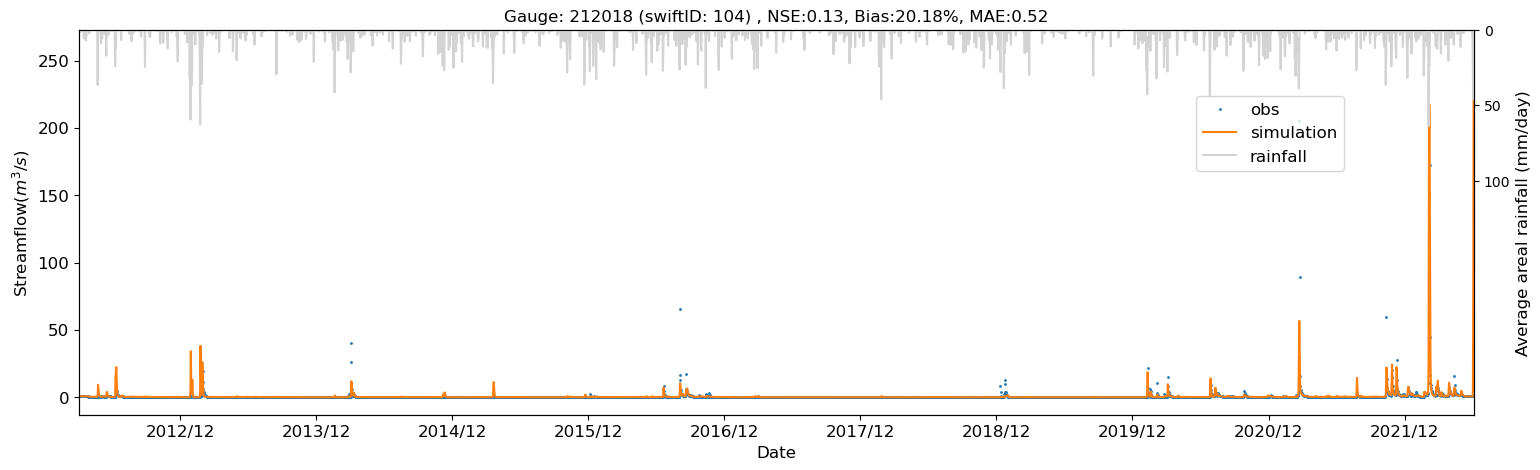

In [75]:
sim_scores = []
sim_scores_bom = []
for i,st_id in enumerate(station_id_sim[:1]):   
    # Finding upstream subareas
    upstream_edges = node_link_utils.find_all_upstream_edges(G, st_id)
    upstream_subareas = [name for _, _, name in upstream_edges]    
    #print(st_id,upstream_subareas)    
    # find indices of upstream_subareas from rain_nc file 
    station_rain_q = cf.lookup(station_id_rain,station_rain,upstream_subareas)
    #print(station_rain_q)
    # take weight of area
    subarea_weight_df1 = subarea_weight_df[subarea_weight_df['station_id'].isin(upstream_subareas)]    
    weight = (subarea_weight_df1['Area_km2'] / subarea_weight_df1['Area_km2'].sum()).values

    rain_upstream = np.squeeze(rain.sel(station=station_rain_q).sel(time=slice(start_date,end_date))['rain_obs'].values)
    # Compute the weighted sum for each row
    if len(upstream_subareas)==1:
        avg_rain_upstream =rain_upstream
    else:   
        avg_rain_upstream = np.dot(rain_upstream, weight)
    fig, axs = plt.subplots(figsize=(18,5))
    st1 = cf.lookup(station_id,station,st_id)
    st2 = cf.lookup(station_id_sim,station_sim,st_id)  
    #print(st_id,st1,st2)
    #find indices of 
    obs1=obs['q_obs'].sel(station=cf.lookup(station_id,station,st_id),time=slice(start_date,end_date))
    sim1=sim_cv['q_sim'].sel(station=cf.lookup(station_id_sim,station_sim,st_id),time=slice(start_date,end_date))
    #sim2=sim_cv_full['q_sim'].sel(station=cf.lookup(station_id_sim_full,station_sim_full,st_id),time=slice(start_date,end_date))   
    obs1.plot(ax=axs,label='obs',linestyle='',marker='.',markersize=2);
    sim1.plot(ax=axs,label='simulation');
    #sim2.plot(ax=axs,label='simulation (Fitzroy)');
    # plot rainfall
    # Create a secondary y-axis for rainfall
    ax2 = axs.twinx()
    ax2.plot(obs1['time'], avg_rain_upstream, label='rainfall',  color=(211/255, 211/255, 211/255))
    # Invert the secondary y-axis
    ax2.invert_yaxis()
    ax2.set_ylim(max(avg_rain_upstream) * 4, 0)  # Correct order for inverted axis
    ax2.set_yticks([100,50,0])
    
    gauge = calibPddf[calibPddf['CalNode']==st_id].index
    # compute NSE values
    sim_val = np.squeeze(sim1.values)
    obs_val = np.squeeze(obs1.values)
    nse = vrf_scores.NSE(sim_val,obs_val)
    kge_res = vrf_scores.KGE(sim_val,obs_val)    
    bias_res = vrf_scores.bias(sim_val,obs_val) 
    rmse = vrf_scores.rmse(sim_val,obs_val)   
    # use scores package
    
    
    #nse2 = vrf_scores.NSE(np.squeeze(sim2.values),np.squeeze(obs1.values))
    #nse_matlab = score_df[score_df['SWIFT_Node_ID']==st_id]['NSE'].values
    #axs.set_title(f"{gauge[0]} ({catchment}), NSE: {nse:2.4f}, from matlab {nse_matlab[0]:2.4f}")
    axs.set_title(f"Gauge: {gauge[0]} (swiftID: {st_id}) , NSE:{nse:2.2f}, Bias:{bias_res['rel']:2.2f}%, MAE:{bias_res['mean_abs_err']:2.2f}")  
    axs.set_xlim([start_date_obj,end_date_obj])
    #axs.set_title(f"swiftID: {st_id} , NSE: {nse:2.4f}") 
    years = mdates.YearLocator()   # every year axs.xaxis.set_major_locator(mdates.MonthLocator(interval=24))
    years_fmt = mdates.DateFormatter('%Y/%m')
    # format the ticks only for years on the major ticks
    axs.xaxis.set_major_locator(years)
    axs.xaxis.set_major_formatter(years_fmt)
    # Getting handles and labels for all lines
    handles1, labels1 = axs.get_legend_handles_labels()
    handles2, labels2 = ax2.get_legend_handles_labels()    
    # Combining legend entries from both axes
    axs.legend(handles1 + handles2, labels1 + labels2, loc='upper left',fontsize=12,bbox_to_anchor=(0.795, 0.85))
    
    #axs.legend(loc='upper left',fontsize=12,bbox_to_anchor=(0.795, 0.85)); 
    axs.set_ylabel('Streamflow($m^3/s$)',fontsize=12)
    axs.set_xlabel('Date',fontsize=12)
    ax2.set_ylabel('Average areal rainfall (mm/day)')  # Correct order for inverted axis
     # Set xticks and yticks fontsize
    axs.tick_params(axis='x', labelsize=12)  # Adjust fontsize as needed
    axs.tick_params(axis='y', labelsize=12)  # Adjust fontsize as needed 
    figname = f"Hydrograph_{catchment}_{rrModel[0]}{routMod[0]}{ecModel[0]}_{calObj[0]}{suffix}_swiftId_{st_id}_{gauge[0]}.png"
    figfile  = os.path.join(fig_dir,figname) 
    #plt.savefig(figfile, dpi=600, bbox_inches='tight')   
    plt.show()
    sim_scores.append([st_id,nse,kge_res['kge'],kge_res['r'],rmse['mean'],bias_res['mean_abs_err'],bias_res['rel'],calObj[0],ecModel[0]])

In [76]:
obs1

<xarray.DataArray 'q_obs' (time: 3745, ens_member: 1, station: 1, lead_time: 1)> Size: 15kB
array([[[[ 0.953]]],


       ...,


       [[[34.348]]]], dtype=float32)
Coordinates:
  * station     (station) float64 8B 1.0
  * lead_time   (lead_time) float64 8B 0.0
  * ens_member  (ens_member) float64 8B 1.0
  * time        (time) datetime64[ns] 30kB 2012-04-05T23:00:00 ... 2022-07-06...
Attributes:
    standard_name:         q_obs
    long_name:             observed streamflow
    units:                 m3/s
    type:                  3
    type_description:      averaged over the preceding interval
    dat_type:              obs
    dat_type_description:  observed
    location_type:         Point

In [77]:
sim1

<xarray.DataArray 'q_sim' (time: 3745, ens_member: 1, station: 1, lead_time: 1)> Size: 15kB
array([[[[  0.75736153]]],


       [[[  0.74072486]]],


       [[[  0.7239542 ]]],


       ...,


       [[[253.70247   ]]],


       [[[259.88742   ]]],


       [[[145.75652   ]]]], dtype=float32)
Coordinates:
  * station     (station) int32 4B 1
  * lead_time   (lead_time) int32 4B 0
  * ens_member  (ens_member) int32 4B 1
  * time        (time) datetime64[ns] 30kB 2012-04-05T23:00:00 ... 2022-07-06...
Attributes:
    standard_name:         q_sim
    long_name:             simulated streamflow
    units:                 m3/s
    type:                  3.0
    type_description:      averaged over the preceding interval
    dat_type:              sim
    dat_type_description:  simulated
    location_type:         point

In [79]:
pwd

['/datasets/work/d61-coastal-forecasting-wp3/work/shr015/Code/python_singularity/swift_notebooks/sim_verf/Hawkesbury']

In [78]:
obs1.to_netcdf('analysis_grid.nc')
sim1.to_netcdf('forecast_grid.nc')

In [81]:
fcst = cf.open_dataset_decode_time("forecast_grid.nc")

In [82]:
fcst

<xarray.Dataset> Size: 45kB
Dimensions:     (station: 1, lead_time: 1, ens_member: 1, time: 3745)
Coordinates:
  * station     (station) int32 4B 1
  * lead_time   (lead_time) int32 4B 0
  * ens_member  (ens_member) int32 4B 1
  * time        (time) datetime64[ns] 30kB 2012-04-05T23:00:00 ... 2022-07-06...
Data variables:
    q_sim       (time, ens_member, station, lead_time) float32 15kB ...

INFO:distributed.scheduler:Scheduler closing...
INFO:distributed.scheduler:Scheduler closing all comms


In [112]:
scores_mae = scores.continuous.mae(sim1,obs1)
scores_rmse = scores.continuous.rmse(sim1,obs1)


In [109]:
scores_mae

<xarray.DataArray ()> Size: 4B
array(0.52237624, dtype=float32)

In [113]:
scores_rmse

<xarray.DataArray ()> Size: 4B
array(6.027638, dtype=float32)

In [111]:
sim_scores[0]

[104,
 0.1298789381980896,
 0.4941535654772137,
 0.7388005882830779,
 6.0276384,
 0.52237624,
 20.181848108768463,
 '7DAY',
 'MAERRIS']

In [77]:
# export scores to csv
# Define the column names
columns = ['SWIFT_ID', 'NSE', 'KGE', 'CORR', 'RMSE', 'MAE', 'PBias', 'calObj', 'ecModel']
# Create the DataFrame
df = pd.DataFrame(sim_scores, columns=columns)

In [78]:
df

,SWIFT_ID,NSE,KGE,CORR,RMSE,MAE,PBias,calObj,ecModel
0,104,0.129879,0.494154,0.738801,6.027638,0.522376,20.181848,7DAY,MAERRIS
1,607,0.796209,0.841812,0.909662,20.093626,2.860860,9.723493,7DAY,MAERRIS
2,611,0.866246,0.775115,0.940563,44.808460,5.730112,-9.603170,7DAY,MAERRIS
3,207,0.564515,0.758935,0.807174,8.175188,1.003641,10.266352,7DAY,MAERRIS
4,512,0.942554,0.867608,0.976415,79.305702,6.513123,-2.621352,7DAY,MAERRIS
5,511,0.702110,0.773357,0.871075,2.711802,0.353477,15.159482,7DAY,MAERRIS
6,515,0.638914,0.582463,0.811704,12.995130,1.913733,-17.995708,7DAY,MAERRIS
7,516,0.464318,0.351801,0.750789,12.446370,1.628470,-20.455705,7DAY,MAERRIS
8,518,0.800171,0.813151,0.899041,9.037959,1.105522,15.673278,7DAY,MAERRIS
9,513,0.860312,0.896176,0.938755,94.247192,16.859882,0.857253,7DAY,MAERRIS


In [79]:
res_dir = os.path.join(rootDir,'SWIFT','Verification','Qsim',catchment)
scores_filename = os.path.join(res_dir, f"sim_stats_qOutput_{catchment}_{rrModel[0]}{routMod[0]}{ecModel[0]}_{calObj[0]}{suffix}.csv")
print(scores_filename)
df.to_csv(scores_filename,index=False)